In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np

In [12]:
# 1. FUNCIONES DE PROCESAMIENTO DE DATOS
# ==========================================================

def calcular_matrices_transicion(rutas):
    """Calcula las matrices de cantidades y probabilidades a partir de una serie de rutas."""
    transiciones = Counter()
    niveles_unicos = set()

    for ruta in rutas.dropna():
        nodos = [n.strip() for n in str(ruta).split('->')]
        niveles_unicos.update(nodos)
        
        for i in range(len(nodos)-1):
            transiciones[(nodos[i], nodos[i+1])] += 1

    niveles = sorted(list(niveles_unicos))
    
    # Matriz de Cantidades
    df_cantidades = pd.DataFrame(0, index=niveles, columns=niveles)
    for (origen, destino), cantidad in transiciones.items():
        df_cantidades.at[origen, destino] = cantidad

    # Matriz de Probabilidades
    df_probabilidades = df_cantidades.div(df_cantidades.sum(axis=1), axis=0).fillna(0)
    
    return df_cantidades, df_probabilidades, transiciones

def extraer_origen_destino_final(valor):
    """Extrae el primer y último nivel de una ruta representada como string de lista."""
    if isinstance(valor, str) and valor.startswith('['):
        try:
            lista = ast.literal_eval(valor)
        except:
            return None
    elif isinstance(valor, list):
        lista = valor
    else:
        return None
    
    if len(lista) > 0:
        return f"{lista[0]} ➔ {lista[-1]}"
    return None

def asignar_periodo(fecha, periodos):
    """Asigna un período de tiempo según la fecha dada."""
    if pd.isna(fecha):
        return 'Sin Dato/Otro'
    
    fecha_str = str(fecha)[:10] 
    for nombre, inicio, fin in periodos:
        if inicio <= fecha_str <= fin:
            return nombre
    return 'Fuera de rango'

In [13]:
# 2. FUNCIONES DE VISUALIZACIÓN
# ==========================================================

def graficar_heatmaps(df_probabilidades, df_cantidades):
    """Grafica los dos heatmaps de transición."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('white')

    # Gráfico 1: Probabilidades
    sns.heatmap(df_probabilidades, annot=True, fmt=".2f", cmap="Blues", 
                linewidths=0.5, linecolor='lightgray', vmin=0, vmax=1, ax=axes[0],
                cbar_kws={'label': 'Probabilidad de Transición'})
    axes[0].set_title("Matriz de Transición (Probabilidades)", fontsize=16, fontweight='bold', pad=15)
    axes[0].set_ylabel("Nivel de Origen", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Nivel de Destino", fontsize=12, fontweight='bold')

    # Gráfico 2: Cantidades
    sns.heatmap(df_cantidades, annot=True, fmt="d", cmap="Oranges", 
                linewidths=0.5, linecolor='lightgray', ax=axes[1],
                cbar_kws={'label': 'Cantidad de Traslados'})
    axes[1].set_title("Matriz de Frecuencia (Cantidades Absolutas)", fontsize=16, fontweight='bold', pad=15)
    axes[1].set_ylabel("Nivel de Origen", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Nivel de Destino", fontsize=12, fontweight='bold')

    for ax in axes:
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='left', fontweight='bold')
        plt.setp(ax.get_yticklabels(), fontweight='bold')

    plt.tight_layout()
    plt.show()

def graficar_top_10(df, x_col, y_col, titulo, xlabel, ylabel, sufijo="pac.", palette="viridis", subtitulo=None):
    """Función genérica para evitar repetir el código de los gráficos de barras horizontales."""
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('white')

    sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)

    margen = df[x_col].max() * 0.015 
    for index, row in df.iterrows():
        texto_etiqueta = f"{int(row[x_col])} {sufijo} ({row['Porcentaje']:.1f}%)"
        ax.text(row[x_col] + margen, index, texto_etiqueta, 
                color='#333333', va="center", fontweight='bold', fontsize=11)

    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')

    if subtitulo:
        plt.figtext(0.5, 0.92, subtitulo, ha="center", fontsize=11, color='dimgray')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='y', labelsize=12)

    plt.show()

def graficar_grilla_periodos(pivot_periodos, orden_columnas):
    """Grafica la evolución de saltos en una grilla 2x2."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor('white')
    axes = axes.flatten()

    colores_periodos = sns.color_palette("Spectral", n_colors=len(orden_columnas))
    max_x = pivot_periodos.max().max() * 1.15

    for idx, periodo in enumerate(orden_columnas):
        ax = axes[idx]
        valores = pivot_periodos[periodo]
        y_pos = np.arange(len(valores))
        
        ax.barh(y_pos, valores, color=colores_periodos[idx], height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(valores.index, fontweight='bold', fontsize=11)
        ax.set_xlim(0, max_x)
        
        ax.set_title(f"{periodo}", fontsize=15, fontweight='bold', pad=10)
        ax.set_xlabel("Traslados", fontsize=11, color='dimgray')
        
        for i, v in enumerate(valores):
            if v > 0:
                ax.text(v + (max_x * 0.015), i, str(int(v)), va='center', fontweight='bold', color='#333333', fontsize=10)

        sns.despine(ax=ax)

    plt.suptitle("Evolución del Top 10 Global de Traslados por Ola", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def graficar_grilla_trayectorias_periodos(pivot_periodos, orden_columnas):
    """Grafica la evolución de trayectorias completas en una grilla 2x2."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor('white')
    axes = axes.flatten()

    colores_periodos = sns.color_palette("Spectral", n_colors=len(orden_columnas))
    max_x = pivot_periodos.max().max() * 1.15

    for idx, periodo in enumerate(orden_columnas):
        ax = axes[idx]
        valores = pivot_periodos[periodo]
        y_pos = np.arange(len(valores))
        
        ax.barh(y_pos, valores, color=colores_periodos[idx], height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(valores.index, fontweight='bold', fontsize=11)
        ax.set_xlim(0, max_x)
        
        ax.set_title(f"{periodo}", fontsize=15, fontweight='bold', pad=10)
        ax.set_xlabel("Pacientes", fontsize=11, color='dimgray')
        
        for i, v in enumerate(valores):
            if v > 0:
                ax.text(v + (max_x * 0.015), i, str(int(v)), va='center', fontweight='bold', color='#333333', fontsize=10)

        sns.despine(ax=ax)

    plt.suptitle("Evolución del Top 10 de Trayectorias Completas por Ola", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def graficar_grilla_trayectorias_dinamico(df_cantidades, df_rankings, orden_columnas, n_top=8):
    """Grafica la evolución de trayectorias marcando el ranking específico de cada período."""
    # Aumentamos un poco el alto (14) porque ahora tendremos más de 10 barras (la unión de los tops)
    fig, axes = plt.subplots(2, 2, figsize=(18, 14)) 
    fig.patch.set_facecolor('white')
    axes = axes.flatten()

    colores_periodos = sns.color_palette("Spectral", n_colors=len(orden_columnas))
    max_x = df_cantidades.max().max() * 1.2 # Damos más margen para que entre el texto del ranking

    for idx, periodo in enumerate(orden_columnas):
        ax = axes[idx]
        valores = df_cantidades[periodo]
        rankings = df_rankings[periodo]
        
        y_pos = np.arange(len(valores))
        
        # LÓGICA DE COLOR: Color del período si está en el Top 8 de este período. Gris claro si no lo está.
        colores_barras = [
            colores_periodos[idx] if not pd.isna(rankings[ruta]) else '#e0e0e0'
            for ruta in valores.index
        ]
        
        ax.barh(y_pos, valores, color=colores_barras, height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(valores.index, fontweight='bold', fontsize=10)
        ax.set_xlim(0, max_x)
        
        ax.set_title(f"{periodo}", fontsize=15, fontweight='bold', pad=10)
        ax.set_xlabel("Pacientes", fontsize=11, color='dimgray')
        
        for i, (ruta, v) in enumerate(valores.items()):
            if v > 0:
                rank = rankings[ruta]
                if not pd.isna(rank):
                    # Texto para los que SON del Top de este período
                    texto = f"[#{int(rank)}]  {int(v)} pac."
                    font_weight = 'bold'
                    color_texto = '#c21807' if rank <= 3 else '#333333' # Rojo oscuro para el podio (Top 1-3)
                else:
                    # Texto para los que NO son del Top de este período
                    texto = f"{int(v)}"
                    font_weight = 'normal'
                    color_texto = 'gray'
                    
                ax.text(v + (max_x * 0.015), i, texto, va='center', fontweight=font_weight, color=color_texto, fontsize=10)

        sns.despine(ax=ax)

    plt.suptitle(f"Evolución Dinámica: Unión de las Top {n_top} Trayectorias por Ola", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [14]:
# 3. INICIO DE GRAFICOS
# ==========================================================

# if __name__ == "__main__":
    
############################################################
# CONFIGURACIÓN Y CARGA DE DATOS
############################################################
RUTA_EXCEL = "C:/Users/micag/Documents/RedesHospitales/data/revision_dfs.xlsx"
PERIODOS_COVID = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]

trayectorias = pd.read_excel(RUTA_EXCEL, sheet_name=2)
df_pacientes = pd.read_excel(RUTA_EXCEL, sheet_name=0) 

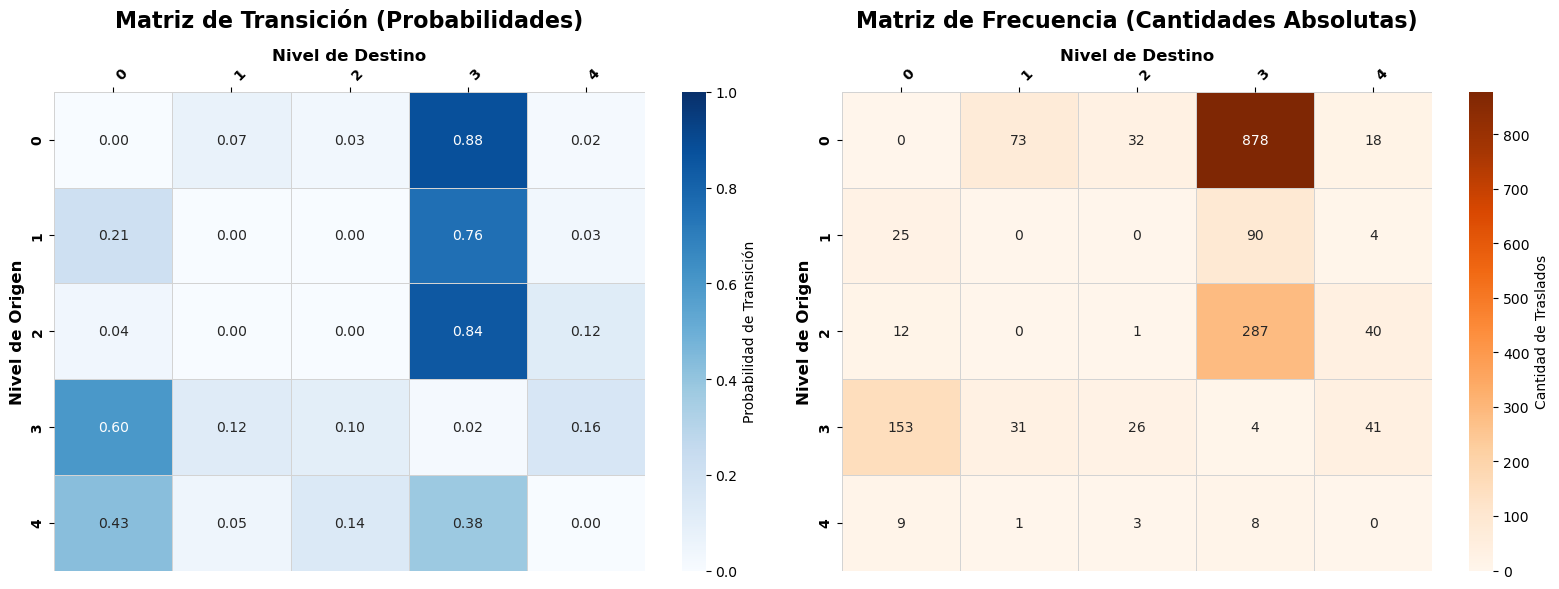

In [15]:
# GRÁFICO 1: MATRICES Y HEATMAPS
############################################################
df_cantidades, df_probabilidades, transiciones = calcular_matrices_transicion(trayectorias['ruta_complejidad_str'])
graficar_heatmaps(df_probabilidades, df_cantidades)

C:\Users\micag\AppData\Local\Temp\ipykernel_13308\99173547.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


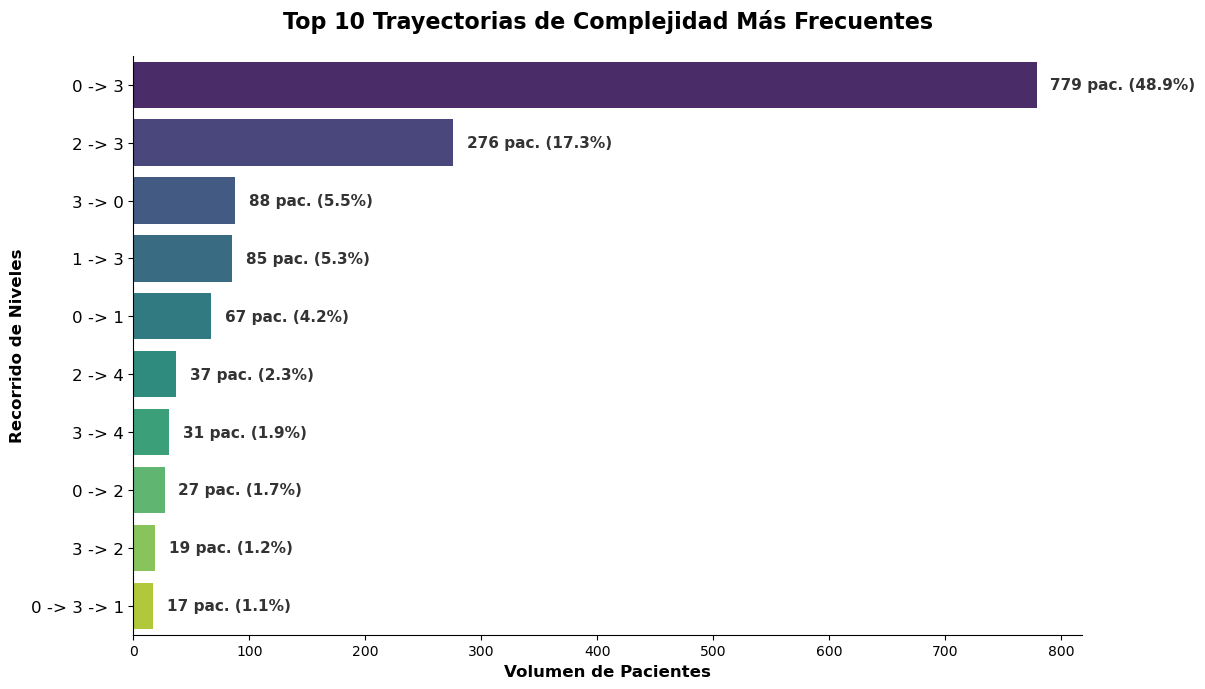

In [16]:
# GRÁFICO 2: TOP 10 TRAYECTORIAS COMPLETAS
############################################################
top_10 = trayectorias['ruta_complejidad_str'].value_counts().head(10).reset_index()
top_10.columns = ['Ruta', 'Frecuencia']
top_10['Porcentaje'] = (top_10['Frecuencia'] / len(trayectorias.dropna(subset=['ruta_complejidad_array']))) * 100

graficar_top_10(
    df=top_10, x_col='Frecuencia', y_col='Ruta',
    titulo="Top 10 Trayectorias de Complejidad Más Frecuentes",
    xlabel="Volumen de Pacientes", ylabel="Recorrido de Niveles", sufijo="pac."
)

C:\Users\micag\AppData\Local\Temp\ipykernel_13308\99173547.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


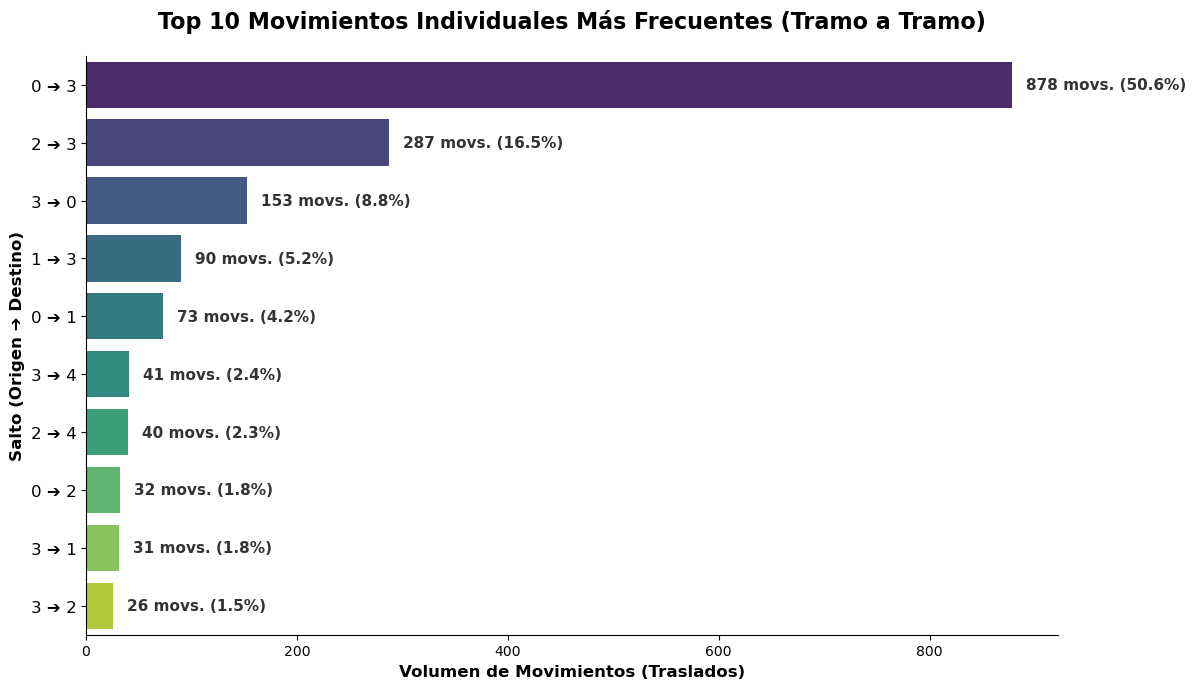

In [17]:
# GRÁFICO 3: TOP 10 SALTOS INDIVIDUALES
############################################################
df_saltos = pd.DataFrame(transiciones.items(), columns=['Salto_Tupla', 'Frecuencia'])
df_saltos['Salto'] = df_saltos['Salto_Tupla'].apply(lambda x: f"{x[0]} ➔ {x[1]}")
top_10_saltos = df_saltos.sort_values(by='Frecuencia', ascending=False).head(10).reset_index(drop=True)
top_10_saltos['Porcentaje'] = (top_10_saltos['Frecuencia'] / df_saltos['Frecuencia'].sum()) * 100

graficar_top_10(
    df=top_10_saltos, x_col='Frecuencia', y_col='Salto',
    titulo="Top 10 Movimientos Individuales Más Frecuentes (Tramo a Tramo)",
    xlabel="Volumen de Movimientos (Traslados)", ylabel="Salto (Origen ➔ Destino)", sufijo="movs."
)

C:\Users\micag\AppData\Local\Temp\ipykernel_13308\99173547.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


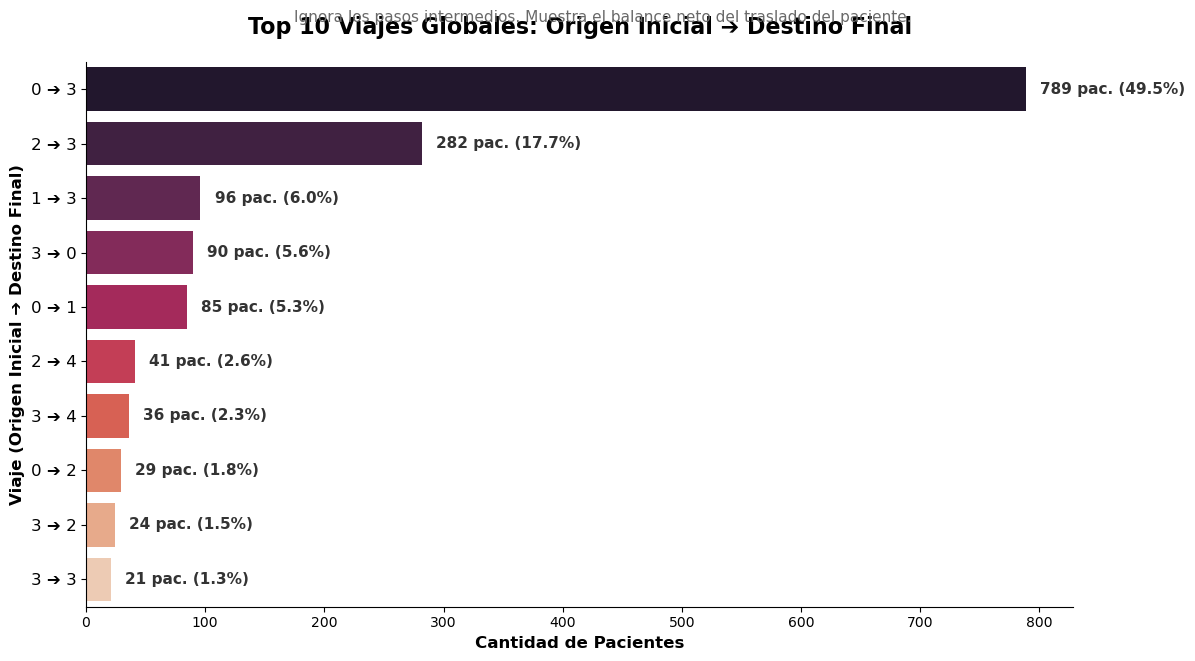

In [18]:
# GRÁFICO 4: VIAJE GLOBAL (ORIGEN ➔ DESTINO)
############################################################
trayectorias['viaje_global'] = trayectorias['ruta_complejidad_array'].apply(extraer_origen_destino_final)
df_viajes = trayectorias.dropna(subset=['viaje_global'])
top_10_viajes = df_viajes['viaje_global'].value_counts().head(10).reset_index()
top_10_viajes.columns = ['Viaje_Global', 'Frecuencia']
top_10_viajes['Porcentaje'] = (top_10_viajes['Frecuencia'] / len(df_viajes)) * 100

graficar_top_10(
    df=top_10_viajes, x_col='Frecuencia', y_col='Viaje_Global',
    titulo="Top 10 Viajes Globales: Origen Inicial ➔ Destino Final",
    xlabel="Cantidad de Pacientes", ylabel="Viaje (Origen Inicial ➔ Destino Final)", sufijo="pac.",
    palette="rocket",
    subtitulo="Ignora los pasos intermedios. Muestra el balance neto del traslado del paciente."
)

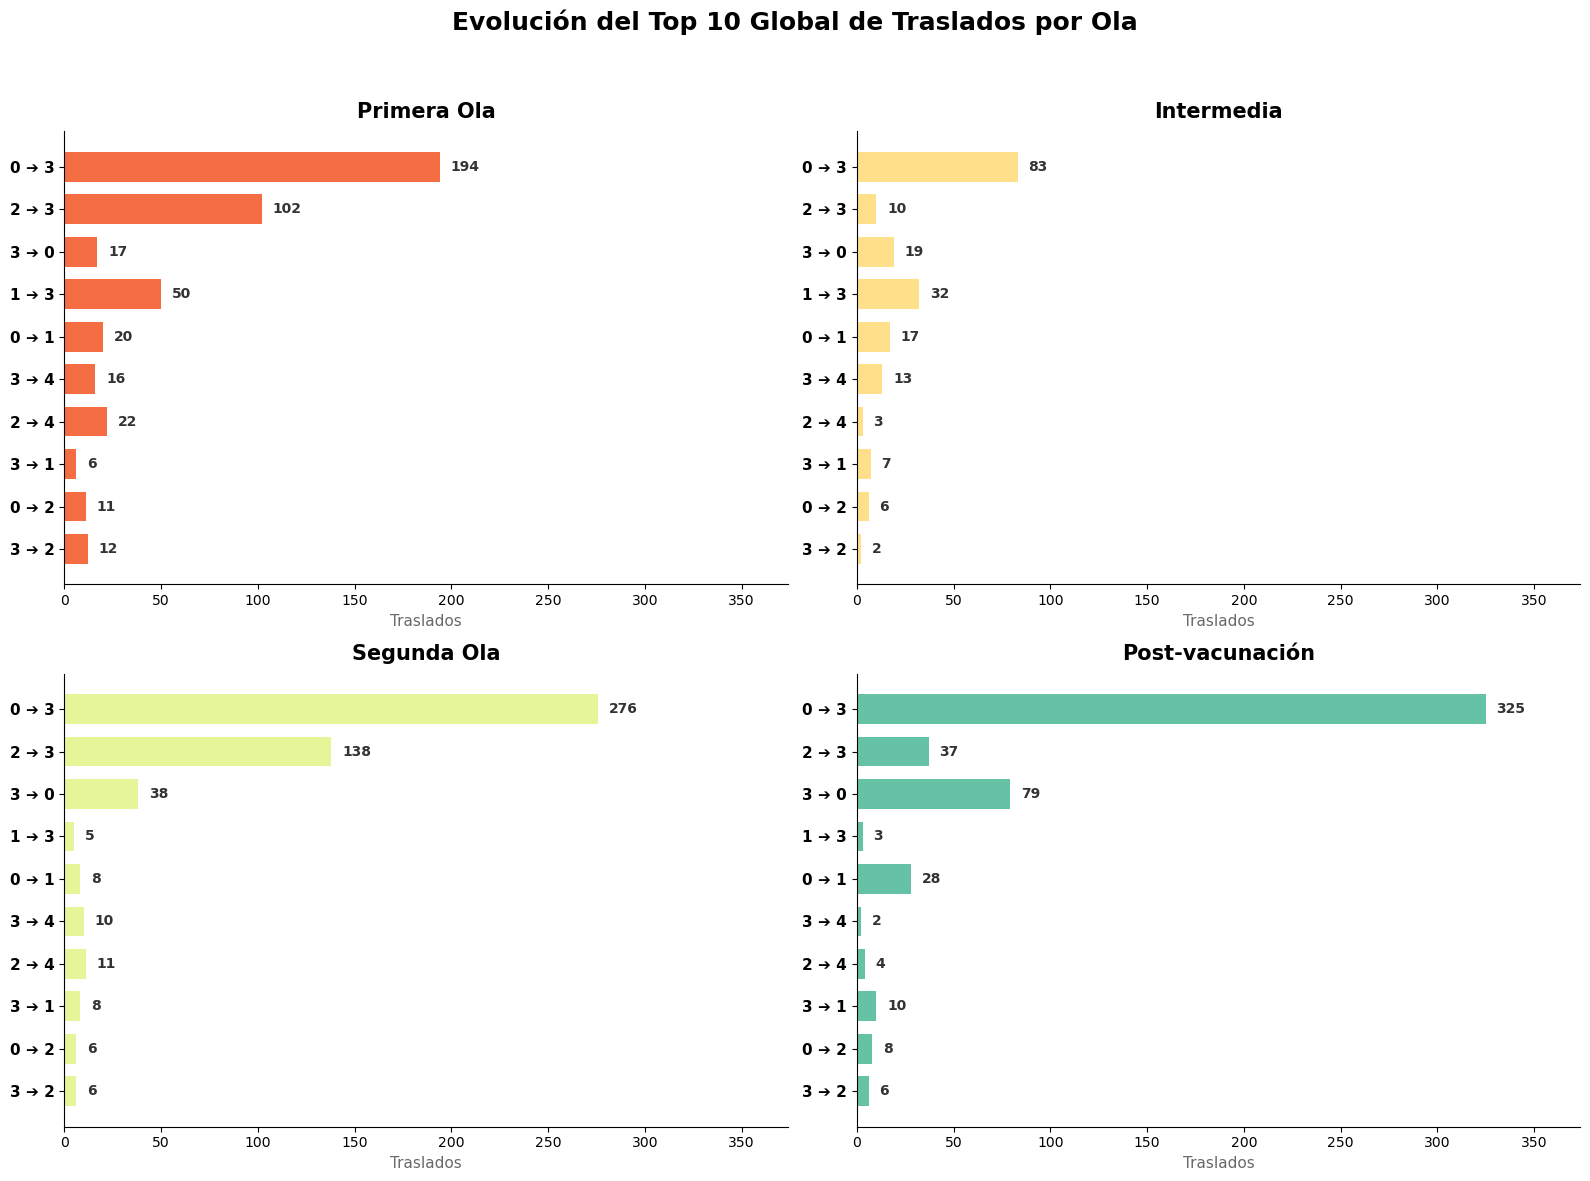

In [19]:
# GRÁFICO 5: ANÁLISIS TEMPORAL (GRILLA POR OLAS COVID)
############################################################
trayectorias['Periodo_Covid'] = trayectorias['fecha_ingreso_trayectoria'].apply(lambda x: asignar_periodo(x, PERIODOS_COVID))

saltos_temporales = []
for _, row in trayectorias.dropna(subset=['ruta_complejidad_str']).iterrows():
    ruta = [n.strip() for n in str(row['ruta_complejidad_str']).split('->')]
    if len(ruta) > 1:
        for i in range(len(ruta) - 1):
            saltos_temporales.append({
                'Salto': f"{ruta[i]} ➔ {ruta[i+1]}",
                'Periodo': row['Periodo_Covid']
            })

df_saltos_temp = pd.DataFrame(saltos_temporales)
nombres_periodos = [p[0] for p in PERIODOS_COVID]
df_saltos_temp = df_saltos_temp[df_saltos_temp['Periodo'].isin(nombres_periodos)]

# Matriz Pivot y visualización
top_10_nombres = df_saltos_temp['Salto'].value_counts().head(10).index
df_top10_temp = df_saltos_temp[df_saltos_temp['Salto'].isin(top_10_nombres)]

pivot_periodos = pd.crosstab(df_top10_temp['Salto'], df_top10_temp['Periodo'])
pivot_periodos['Total'] = pivot_periodos.sum(axis=1)
pivot_periodos = pivot_periodos.sort_values('Total', ascending=True).drop(columns=['Total'])

orden_columnas_existentes = [p for p in nombres_periodos if p in pivot_periodos.columns]
pivot_periodos = pivot_periodos[orden_columnas_existentes]

graficar_grilla_periodos(pivot_periodos, orden_columnas_existentes)

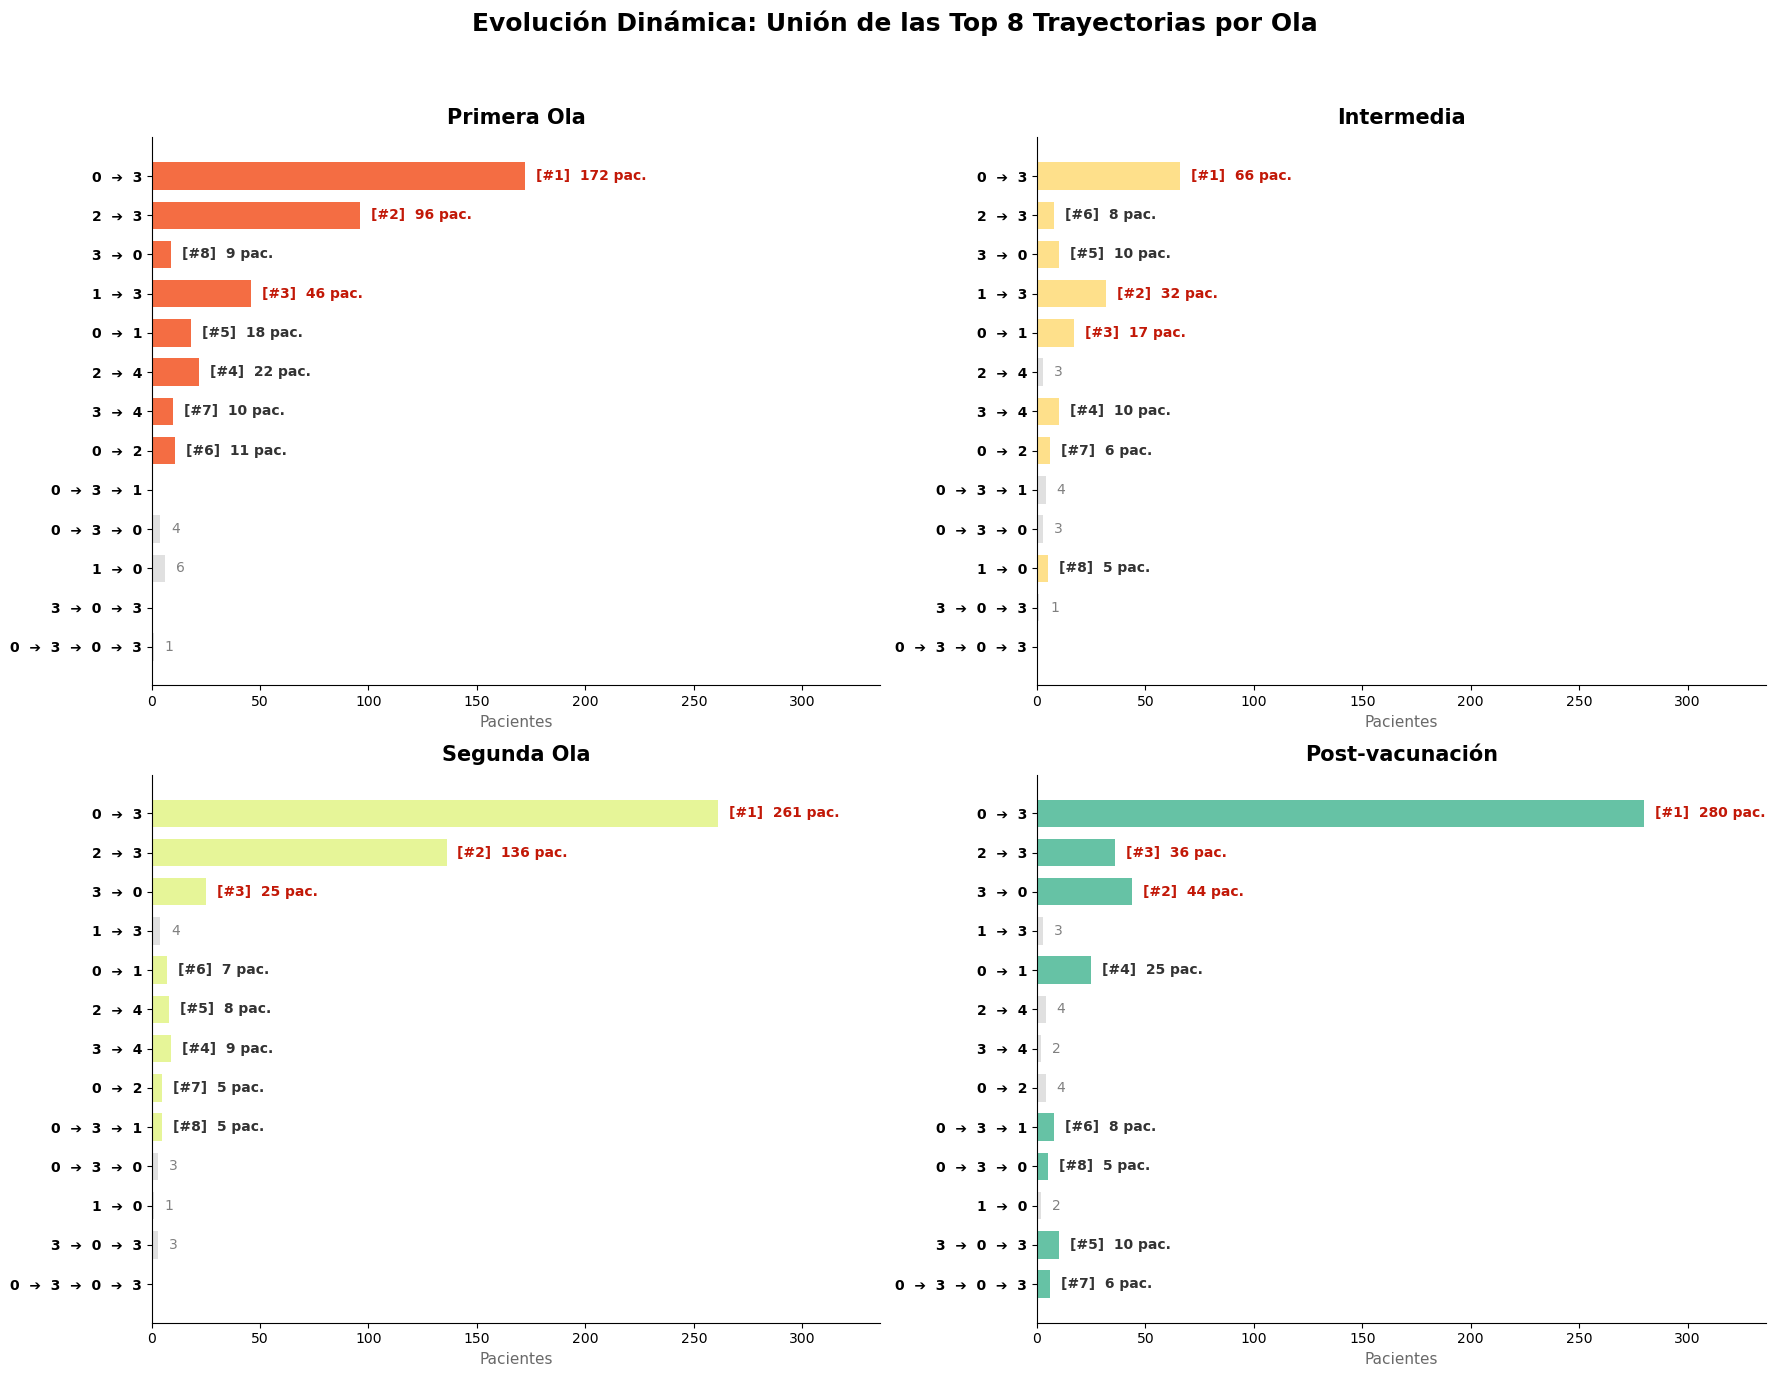

In [20]:
# GRÁFICO 6: TRAYECTORIAS COMPLETAS CON RANKING DINÁMICO
############################################################
N_TOP = 8
nombres_periodos = [p[0] for p in PERIODOS_COVID]

df_trayectorias_validas = trayectorias[
    (trayectorias['Periodo_Covid'].isin(nombres_periodos)) & 
    (trayectorias['ruta_complejidad_str'].notna())
].copy()

df_trayectorias_validas['ruta_formateada'] = df_trayectorias_validas['ruta_complejidad_str'].apply(
    lambda x: str(x).replace('->', ' ➔ ')
)

# 1. Identificar el Top 8 independiente para cada período
top_por_periodo = {}
rutas_union = set()

for periodo in nombres_periodos:
    df_periodo = df_trayectorias_validas[df_trayectorias_validas['Periodo_Covid'] == periodo]
    conteos_periodo = df_periodo['ruta_formateada'].value_counts().head(N_TOP)
    top_por_periodo[periodo] = conteos_periodo
    rutas_union.update(conteos_periodo.index)

# 2. Ordenar las rutas de la unión por su volumen GLOBAL (para que el eje Y esté ordenado lógicamente)
# Lo hacemos ascendente para que las más frecuentes queden arriba en el gráfico de barras horizontales
volumen_global = df_trayectorias_validas[
    df_trayectorias_validas['ruta_formateada'].isin(rutas_union)
]['ruta_formateada'].value_counts(ascending=True)
rutas_ordenadas = volumen_global.index.tolist()

# 3. Construir las dos matrices que necesita la función: una de Cantidades y otra de Rankings
df_cantidades = pd.DataFrame(0, index=rutas_ordenadas, columns=nombres_periodos)
df_rankings = pd.DataFrame(np.nan, index=rutas_ordenadas, columns=nombres_periodos)

for periodo in nombres_periodos:
    # Llenar matriz de cantidades (incluso para las que no están en el top de este período)
    cantidades_totales_periodo = df_trayectorias_validas[
        df_trayectorias_validas['Periodo_Covid'] == periodo
    ]['ruta_formateada'].value_counts()
    
    for ruta in rutas_ordenadas:
        df_cantidades.at[ruta, periodo] = cantidades_totales_periodo.get(ruta, 0)
    
    # Llenar matriz de rankings (SOLO para las que entraron al Top 8 de este período)
    if periodo in top_por_periodo:
        top_rutas = top_por_periodo[periodo].index
        for rank, ruta in enumerate(top_rutas, 1): # Enumeramos desde el 1 al 8
            df_rankings.at[ruta, periodo] = rank

# 4. Graficar
graficar_grilla_trayectorias_dinamico(df_cantidades, df_rankings, nombres_periodos, n_top=N_TOP)